## Association Rule Mining for Market Basket Analysis
-----------------------------------------------------------------------------

Association Rule Mining is a powerful data mining technique used to uncover patterns and relationships within datasets. This technique has broad applications across various industries, enabling businesses to make informed decisions by understanding the relationships between different items or events.

We will focus on using Market Basket Analysis, a specific implementation of Association Rule Mining, to analyze retail data.

### How the Apriori Algorithm Works
1) Generate Candidate Itemsets: The algorithm starts by generating candidate itemsets of size 1. It then scans the dataset to count the support of each itemset and removes those that do not meet the minimum support threshold.

2) Generate Larger Itemsets: Using the frequent itemsets of size 1, the algorithm generates candidate itemsets of size 2, then size 3, and so on. For each size, it scans the dataset to count support and filters out infrequent itemsets.

3) Generate Association Rules: Once all frequent itemsets are identified, the algorithm generates association rules from these itemsets. Each rule is evaluated based on its confidence and lift, and only those that meet the minimum thresholds are retained.

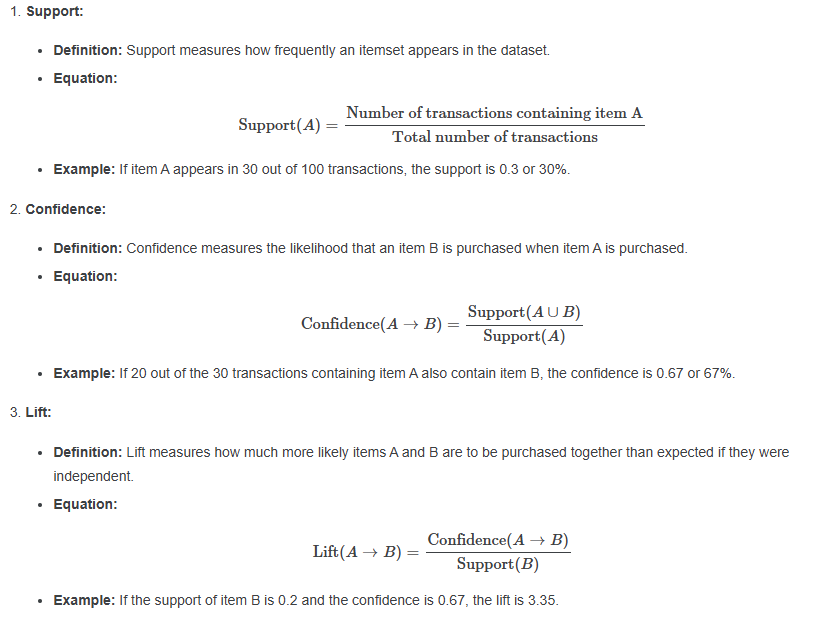

### Import required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

In [2]:
df = pd.read_csv("../datasets/basket_analysis.csv")
df.shape

(999, 17)

In [3]:
df.head()

,Unnamed: 0,Apple,Bread,Butter,Cheese,Corn,Dill,Eggs,Ice cream,Kidney Beans,Milk,Nutmeg,Onion,Sugar,Unicorn,Yogurt,chocolate
0,0,False,True,False,False,True,True,False,True,False,False,False,False,True,False,True,True
1,1,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2,2,True,False,True,False,False,True,False,True,False,True,False,False,False,False,True,True
3,3,False,False,True,True,False,True,False,False,False,True,True,True,False,False,False,False
4,4,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [4]:
df.tail()

,Unnamed: 0,Apple,Bread,Butter,Cheese,Corn,Dill,Eggs,Ice cream,Kidney Beans,Milk,Nutmeg,Onion,Sugar,Unicorn,Yogurt,chocolate
994,994,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,True
995,995,True,False,False,False,True,False,False,False,True,True,True,False,False,False,True,False
996,996,True,False,False,False,True,True,False,False,False,False,False,False,True,False,False,True
997,997,False,False,True,True,True,False,True,True,True,False,True,False,True,False,True,True
998,998,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True


In [5]:
df.sample(10)

,Unnamed: 0,Apple,Bread,Butter,Cheese,Corn,Dill,Eggs,Ice cream,Kidney Beans,Milk,Nutmeg,Onion,Sugar,Unicorn,Yogurt,chocolate
787,787,False,True,False,True,False,False,True,False,False,False,False,False,False,True,False,False
640,640,False,True,True,False,False,False,False,True,True,True,False,True,True,True,False,False
134,134,False,False,False,False,False,False,False,False,True,False,True,False,True,False,False,False
733,733,True,True,False,False,False,True,False,False,True,False,True,False,True,False,True,True
356,356,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
479,479,True,False,False,True,False,True,True,False,False,False,True,True,False,False,False,False
346,346,True,False,False,True,True,False,True,False,False,True,True,True,False,True,True,False
581,581,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
828,828,False,True,True,True,False,True,True,False,False,True,True,False,False,True,False,True
628,628,True,True,True,False,True,True,False,True,False,False,True,False,True,True,True,True


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Unnamed: 0    999 non-null    int64
 1   Apple         999 non-null    bool 
 2   Bread         999 non-null    bool 
 3   Butter        999 non-null    bool 
 4   Cheese        999 non-null    bool 
 5   Corn          999 non-null    bool 
 6   Dill          999 non-null    bool 
 7   Eggs          999 non-null    bool 
 8   Ice cream     999 non-null    bool 
 9   Kidney Beans  999 non-null    bool 
 10  Milk          999 non-null    bool 
 11  Nutmeg        999 non-null    bool 
 12  Onion         999 non-null    bool 
 13  Sugar         999 non-null    bool 
 14  Unicorn       999 non-null    bool 
 15  Yogurt        999 non-null    bool 
 16  chocolate     999 non-null    bool 
dtypes: bool(16), int64(1)
memory usage: 23.5 KB


In [7]:
df.isnull().sum()

Unnamed: 0      0
Apple           0
Bread           0
Butter          0
Cheese          0
Corn            0
Dill            0
Eggs            0
Ice cream       0
Kidney Beans    0
Milk            0
Nutmeg          0
Onion           0
Sugar           0
Unicorn         0
Yogurt          0
chocolate       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [46]:
frequent_itemsets = apriori(df, min_support=0.02, use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.383383,(Apple)
1,0.384384,(Bread)
2,0.420420,(Butter)
3,0.404404,(Cheese)
4,0.407407,(Corn)
...,...,...
5540,0.020020,"(Ice cream, Dill, Kidney Beans, Onion, Cheese,..."
5541,0.021021,"(Unicorn, chocolate, Dill, Kidney Beans, Onion..."
5542,0.020020,"(chocolate, Sugar, Ice cream, Kidney Beans, Ch..."
5543,0.020020,"(Unicorn, chocolate, Yogurt, Corn, Onion, Nutmeg)"


In [47]:
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1)

rules["itemset_size"] = rules["antecedents"].apply(len) + rules["consequents"].apply(len)

rules["itemset"] = rules.apply(
    lambda row: ", ".join(list(row["antecedents"])) + " -> " +
                ", ".join(list(row["consequents"])),
    axis=1
)

rules.sort_values(by="lift", ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,itemset_size,itemset
118580,"(Cheese, Apple, Unicorn)","(Sugar, Corn, Kidney Beans)",0.075075,0.090090,0.022022,0.293333,3.256000,1.0,0.015259,1.287608,0.749115,0.153846,0.223366,0.268889,6,"Cheese, Apple, Unicorn -> Sugar, Corn, Kidney ..."
118581,"(Sugar, Corn, Kidney Beans)","(Cheese, Apple, Unicorn)",0.090090,0.075075,0.022022,0.244444,3.256000,1.0,0.015259,1.224165,0.761476,0.153846,0.183117,0.268889,6,"Sugar, Corn, Kidney Beans -> Cheese, Apple, Un..."
118455,"(Apple, Unicorn, Bread)","(Sugar, Corn, Yogurt)",0.076076,0.085085,0.020020,0.263158,3.092879,1.0,0.013547,1.241670,0.732394,0.141844,0.194633,0.249226,6,"Apple, Unicorn, Bread -> Sugar, Corn, Yogurt"
118458,"(Sugar, Corn, Yogurt)","(Apple, Unicorn, Bread)",0.085085,0.076076,0.020020,0.235294,3.092879,1.0,0.013547,1.208208,0.739606,0.141844,0.172328,0.249226,6,"Sugar, Corn, Yogurt -> Apple, Unicorn, Bread"
119204,"(chocolate, Kidney Beans, Onion)","(Cheese, Unicorn, Dill)",0.083083,0.082082,0.021021,0.253012,3.082427,1.0,0.014201,1.228826,0.736796,0.145833,0.186215,0.254555,6,"chocolate, Kidney Beans, Onion -> Cheese, Unic..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3764,"(Apple, Dill)","(Cheese, Bread)",0.179179,0.173173,0.031031,0.173184,1.000065,1.0,0.000002,1.000014,0.000079,0.096573,0.000014,0.176188,4,"Apple, Dill -> Cheese, Bread"
715,(Onion),"(Apple, Kidney Beans)",0.403403,0.176176,0.071071,0.176179,1.000014,1.0,0.000001,1.000003,0.000024,0.139764,0.000003,0.289794,3,"Onion -> Apple, Kidney Beans"
710,"(Apple, Kidney Beans)",(Onion),0.176176,0.403403,0.071071,0.403409,1.000014,1.0,0.000001,1.000010,0.000017,0.139764,0.000010,0.289794,3,"Apple, Kidney Beans -> Onion"
4314,"(Ice cream, Apple, Bread)",(Milk),0.074074,0.405405,0.030030,0.405405,1.000000,1.0,0.000000,1.000000,0.000000,0.066815,0.000000,0.239740,4,"Ice cream, Apple, Bread -> Milk"


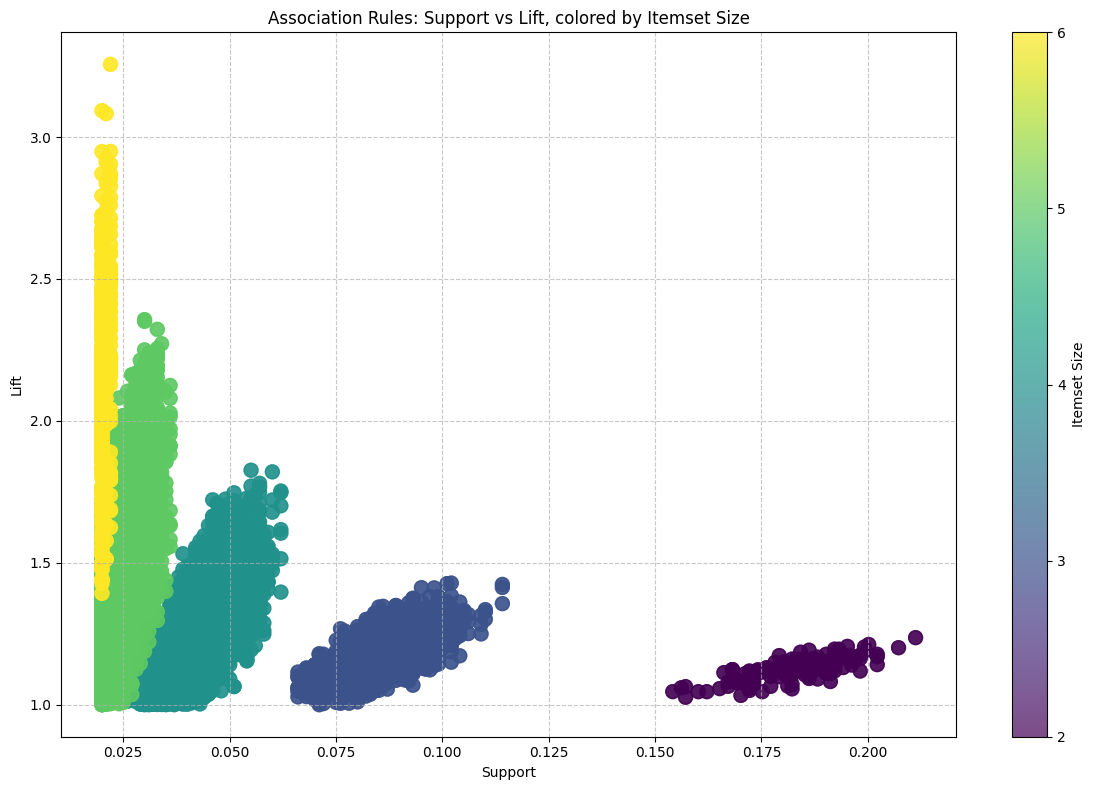

In [48]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    rules["support"],
    rules["lift"],
    c = rules["itemset_size"],
    cmap="viridis",
    alpha=0.7,
    s=100
)

cbar = plt.colorbar(scatter, label="Itemset Size")
cbar.set_ticks(list(range(2, rules["itemset_size"].max() + 1)))

plt.xlabel("Support")
plt.ylabel("Lift")
plt.title("Association Rules: Support vs Lift, colored by Itemset Size")

plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

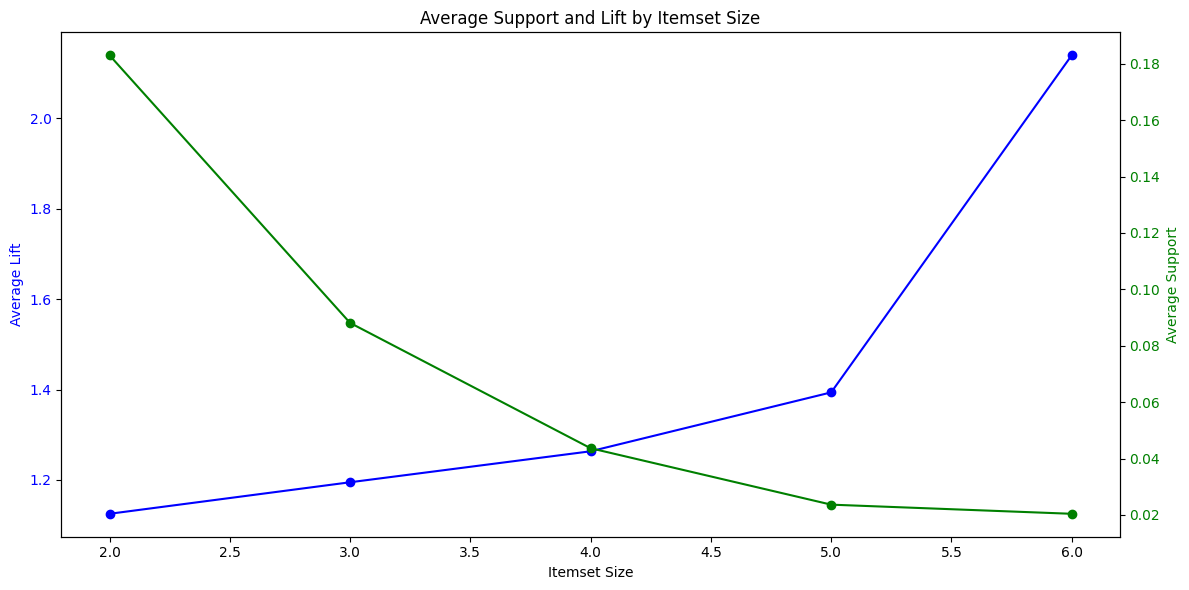

In [ ]:
### Average support and Lift by Itemset Size

# Group by itemset size and calculate average support and lift
average_metrics = rules.groupby('itemset_size').agg({'support': 'mean', 'lift': 'mean'}).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot average lift on the primary y-axis
ax1.plot(average_metrics['itemset_size'], average_metrics['lift'], marker='o', color='b', label='Average Lift')
ax1.set_xlabel('Itemset Size')
ax1.set_ylabel('Average Lift', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Create a secondary y-axis to plot average support
ax2 = ax1.twinx()
ax2.plot(average_metrics['itemset_size'], average_metrics['support'], marker='o', color='g', label='Average Support')
ax2.set_ylabel('Average Support', color='g')
ax2.tick_params(axis='y', labelcolor='g')

# Adding title and legend
plt.title('Average Support and Lift by Itemset Size')
fig.tight_layout()

# Show the plot
plt.show()

In [60]:
rules_sorted = rules.sort_values(by=["itemset_size", "lift", "support"], ascending=[True, False, False])
top_rules = rules_sorted.groupby("itemset_size").head(1).reset_index(drop=True)

top_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,itemset_size,itemset
0,(Milk),(chocolate),0.405405,0.421421,0.211211,0.520988,1.236263,1.0,0.040365,1.207857,0.321413,0.343089,0.172088,0.511088,2,Milk -> chocolate
1,"(Cheese, Dill)",(Onion),0.177177,0.403403,0.102102,0.576271,1.428523,1.0,0.030628,1.407968,0.364570,0.213389,0.289757,0.414686,3,"Cheese, Dill -> Onion"
2,"(Cheese, Dill)","(Kidney Beans, Onion)",0.177177,0.170170,0.055055,0.310734,1.826022,1.0,0.024905,1.203933,0.549768,0.188356,0.169389,0.317132,4,"Cheese, Dill -> Kidney Beans, Onion"
3,"(Apple, Unicorn, Eggs)","(Sugar, Corn)",0.068068,0.187187,0.030030,0.441176,2.356873,1.0,0.017289,1.454507,0.617759,0.133333,0.312482,0.300802,5,"Apple, Unicorn, Eggs -> Sugar, Corn"
4,"(Cheese, Apple, Unicorn)","(Sugar, Corn, Kidney Beans)",0.075075,0.090090,0.022022,0.293333,3.256000,1.0,0.015259,1.287608,0.749115,0.153846,0.223366,0.268889,6,"Cheese, Apple, Unicorn -> Sugar, Corn, Kidney ..."


   itemset_size  confidence
4             6    0.266163
3             5    0.228275
2             4    0.274959
1             3    0.350207
0             2    0.453774


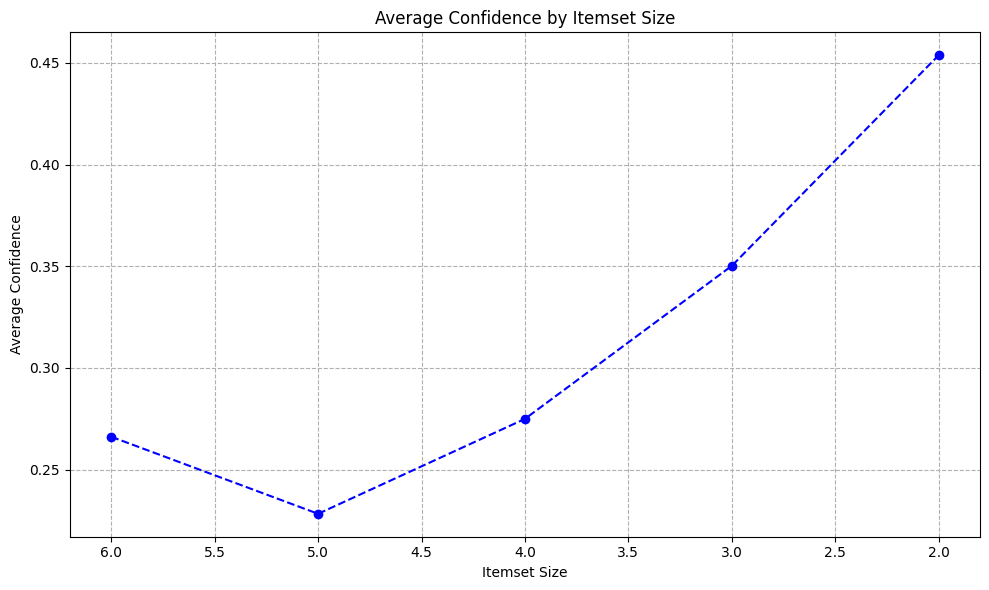

In [72]:
avg_confidence = rules.groupby("itemset_size")["confidence"].mean().reset_index().sort_values(by="itemset_size", ascending=False)
print(avg_confidence)

plt.figure(figsize=(10, 6))
plt.plot(avg_confidence["itemset_size"], avg_confidence["confidence"], marker='o', linestyle="--", color="b")

plt.xlabel("Itemset Size")
plt.ylabel("Average Confidence")
plt.title("Average Confidence by Itemset Size")

plt.gca().invert_xaxis()
plt.grid(True, linestyle="--")

plt.tight_layout()
plt.show()